# Analiza Porównawcza Algorytmów Detekcji Naczyń Krwionośnych
Porównanie algorytmów na 5 obrazach testowych z folderu `data/test/`.

- **Macierz pomyłek** (TP, TN, FP, FN)
- **Czułość (Sensitivity / TPR)** - jak dużo rzeczywistych naczyń zostało wykrytych.
- **Swoistość (Specificity / TNR)** - jak dużo rzeczywistego tła zostało poprawnie zignorowane.
- **Zbalansowaną trafność (Balanced Accuracy)** - średnia arytmetyczna z czułości i swoistości.
- **G-Mean (Średnia geometryczna)** - popularna miara dla danych niezrównoważonych, pierwiastek z iloczynu czułości i swoistości.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
from IPython.display import display
import warnings

# Import uniwersalnego detektora z naszego projektu
from detect import VesselDetector

### 1. Inicjalizacja detektorów i ścieżek

In [2]:
TEST_INPUT_DIR = Path("./data/test/input/")
TEST_LABEL_DIR = Path("./data/test/label/")
SUPPORTED_EXTS = {".ppm", ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

test_images = sorted([p for p in TEST_INPUT_DIR.iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS])[:5]

if len(test_images) < 5:
    print(f"Uwaga: Znaleziono tylko {len(test_images)} obrazów. Wymagane było minimum 5.")
else:
    print(f"Znaleziono {len(test_images)} obrazów do analizy.")

print("\nŁadowanie algorytmów...")
print("1/3: U-Net")
detector_unet = VesselDetector(model_path="./model/unet_vessels.pth", threshold=0.5)

print("2/3: Random Forest")
detector_rf = VesselDetector(model_path="./model/rf_vessels.joblib")

print("3/3: Basic Image Processing")
detector_ip = VesselDetector(model_path="basic_ip")

detectors = {
    "U-Net": detector_unet,
    "Random Forest": detector_rf,
    "Basic IP": detector_ip
}

Znaleziono 5 obrazów do analizy.

Ładowanie algorytmów...
1/3: U-Net
Inicjalizacja modelu U-Net na urządzeniu: cuda
2/3: Random Forest
3/3: Basic Image Processing


### 2. Definicja funkcji ewaluacyjnej

In [3]:
def calculate_metrics(y_true_mask, y_pred_mask):
    # Spłaszczenie masek (zamiana 2D obrazka na 1D wektor pikseli)
    y_true = (y_true_mask > 0).ravel()
    y_pred = (y_pred_mask > 0).ravel()
    
    # Wyznaczenie macierzy pomyłek
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    # Podstawowe miary
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    # Miary dla danych niezrównoważonych
    balanced_accuracy = (sensitivity + specificity) / 2.0
    g_mean = np.sqrt(sensitivity * specificity)
    
    return {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced Acc": balanced_accuracy,
        "G-Mean": g_mean
    }

### 3. Testowanie obrazów i wizualizacja wyników

Przetwarzanie obrazu 1/5: im0001.ppm
Ekstrakcja cech dla 311469 pikseli...
Przetwarzanie obrazu 2/5: im0002.ppm
Ekstrakcja cech dla 285782 pikseli...
Przetwarzanie obrazu 3/5: im0003.ppm
Ekstrakcja cech dla 314528 pikseli...
Przetwarzanie obrazu 4/5: im0004.ppm
Ekstrakcja cech dla 289707 pikseli...
Przetwarzanie obrazu 5/5: im0005.ppm
Ekstrakcja cech dla 315186 pikseli...


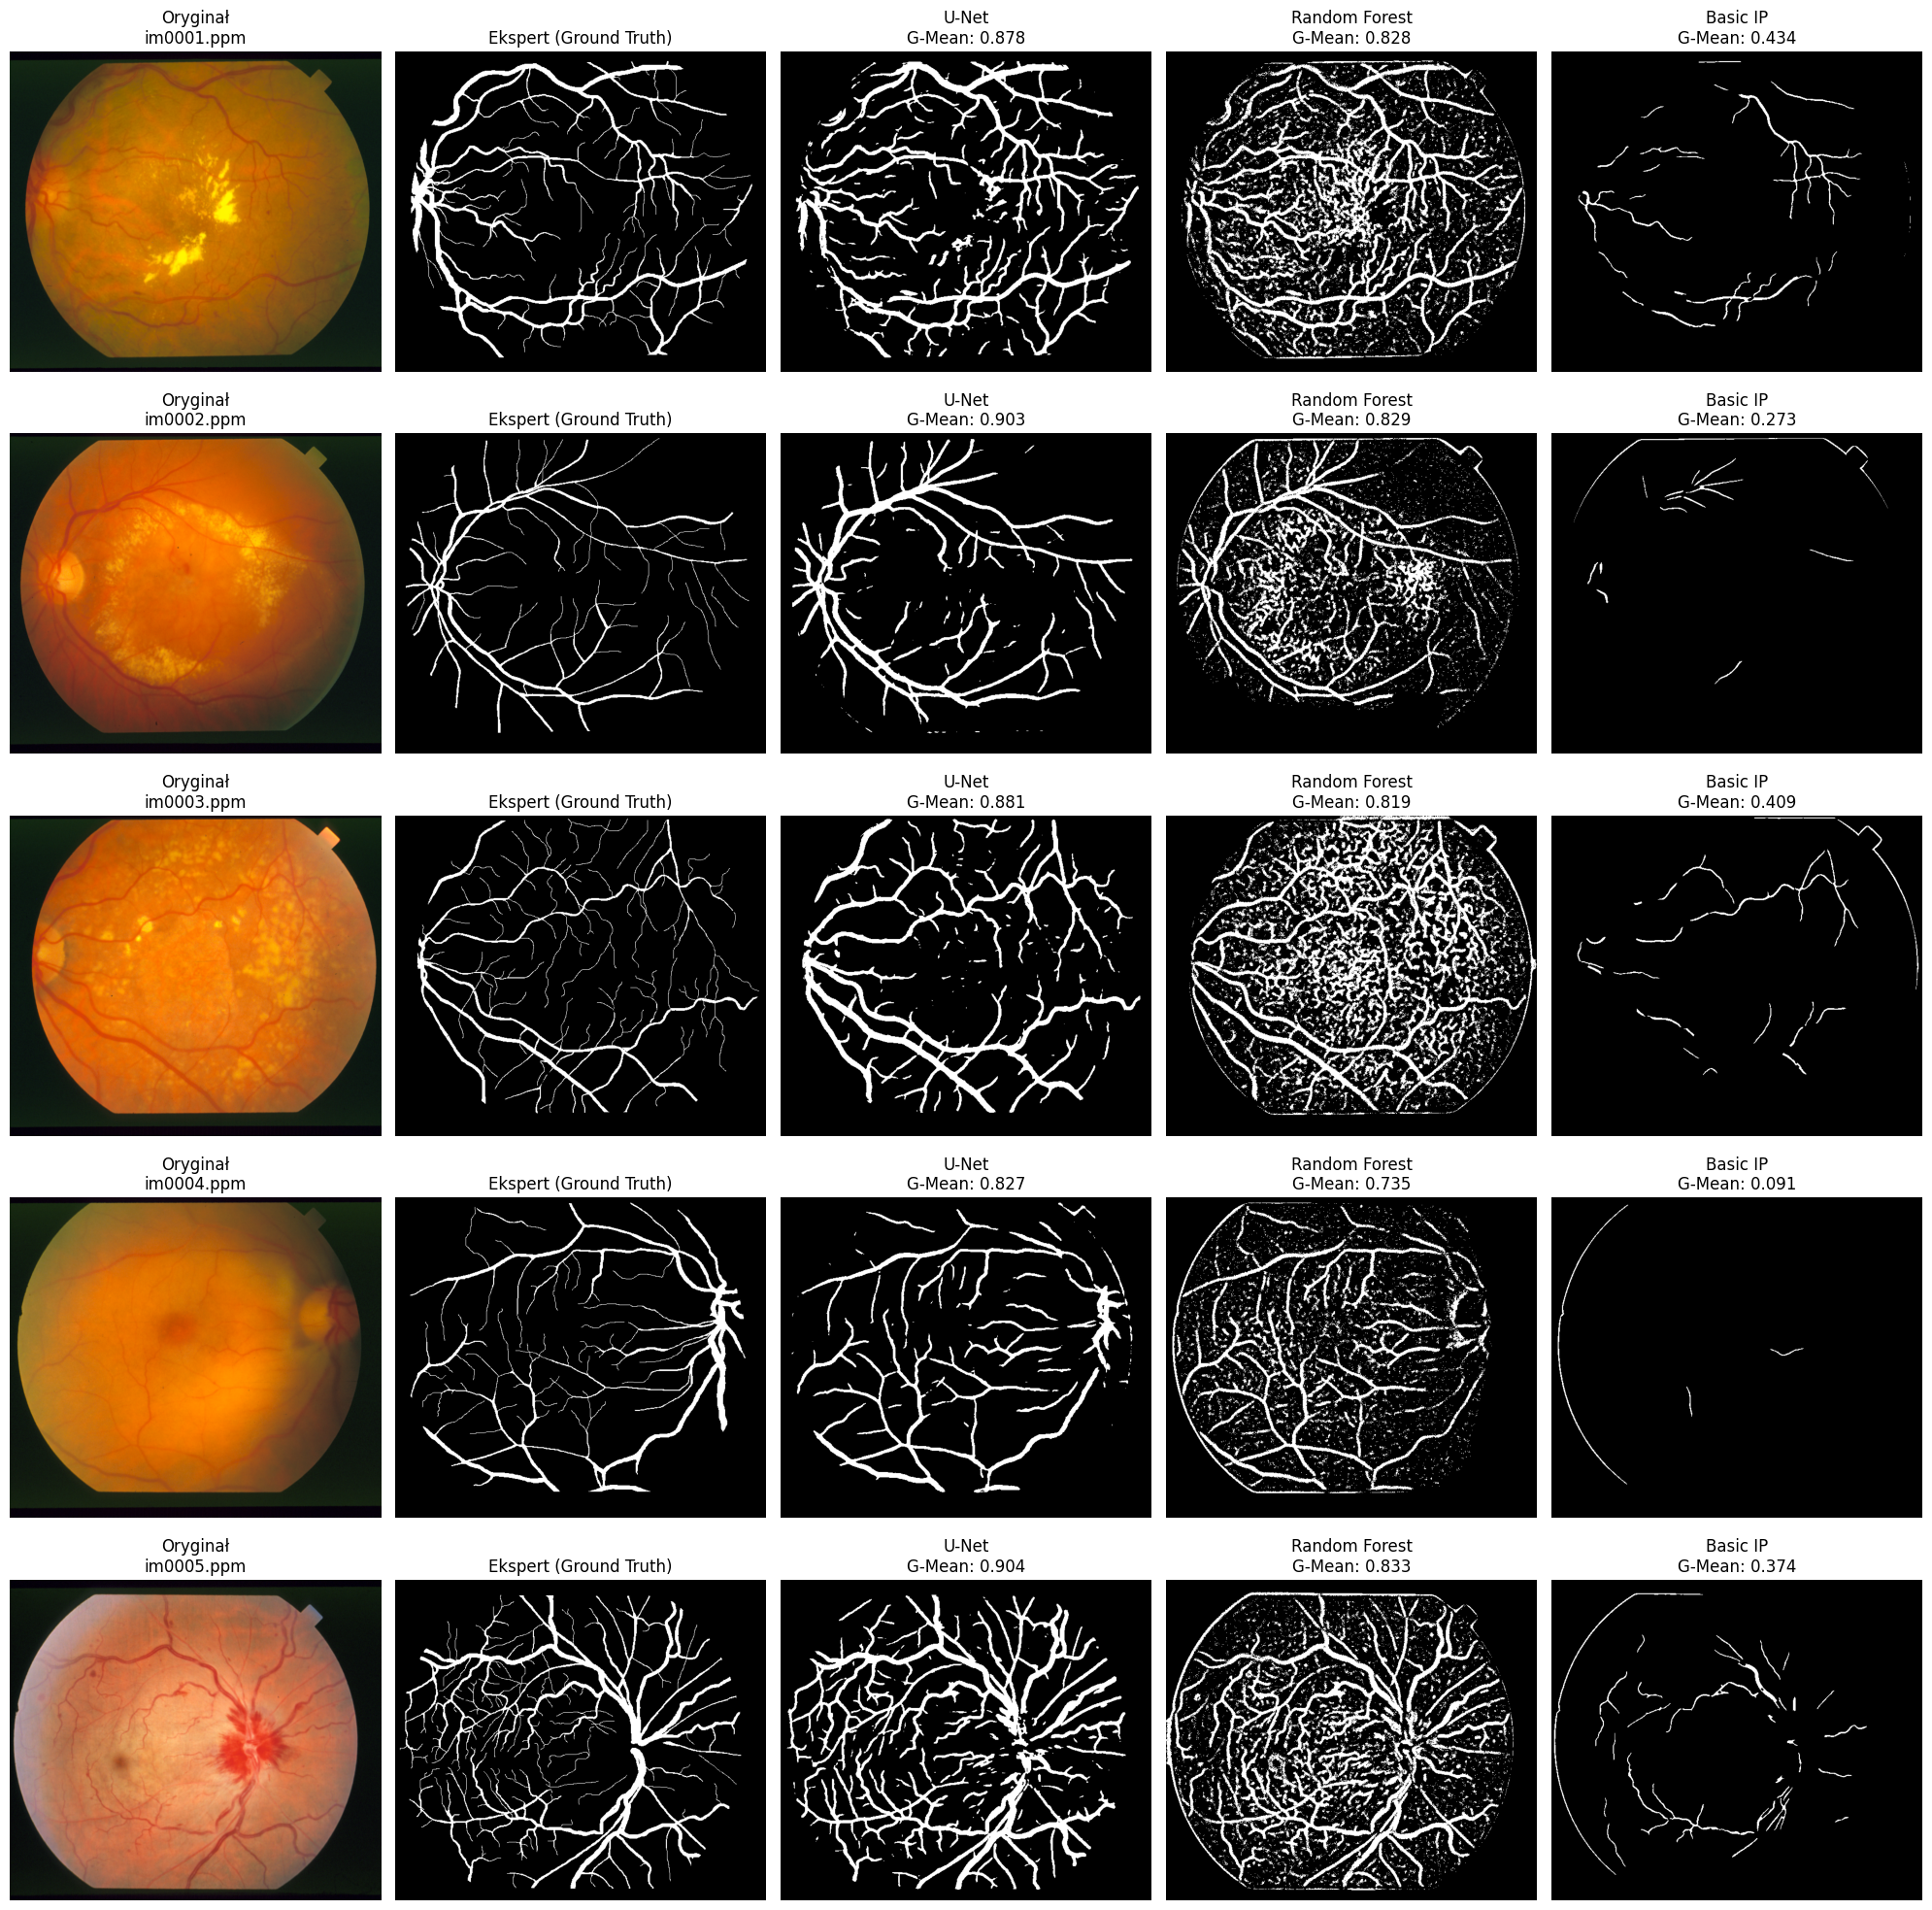

In [4]:
results = []

# Inicjalizacja okna z wykresami (5 obrazów x 5 kolumn do wyświetlenia)
fig, axes = plt.subplots(len(test_images), 5, figsize=(20, 4*len(test_images)))

for i, img_path in enumerate(test_images):
    print(f"Przetwarzanie obrazu {i+1}/{len(test_images)}: {img_path.name}")
    
    # Wczytanie oryginału i maski eksperckiej
    rgb_image = Image.open(img_path).convert("RGB")
    
    label_candidates = [l for l in TEST_LABEL_DIR.iterdir() if l.is_file() and img_path.stem in l.name]
    if not label_candidates:
        print(f" -> Brak maski eksperckiej, pomijanie...")
        continue
    gt_mask = np.array(Image.open(label_candidates[0]).convert("L"))
    
    # Wyświetlenie obrazka oryg.
    axes[i, 0].imshow(rgb_image)
    axes[i, 0].set_title(f"Oryginał\n{img_path.name}")
    axes[i, 0].axis("off")
    
    # Wyświetlenie ground truth
    axes[i, 1].imshow(gt_mask, cmap="gray")
    axes[i, 1].set_title("Ekspert (Ground Truth)")
    axes[i, 1].axis("off")
    
    col_idx = 2
    for model_name, detector in detectors.items():
        # Predykcja na obrazie
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pred_mask = detector.detect(str(img_path))
            
        # Dopasowanie rozmiaru w razie rozbieżności (np. U-Net)
        if pred_mask.shape != gt_mask.shape:
            pred_mask = np.array(Image.fromarray(pred_mask).resize(gt_mask.shape[::-1], Image.NEAREST))
            
        # Obliczanie metryk
        metrics = calculate_metrics(gt_mask, pred_mask)
        metrics["Obraz"] = img_path.name
        metrics["Algorytm"] = model_name
        results.append(metrics)
        
        # Wyświetlanie wyniku predykcji na siatce
        axes[i, col_idx].imshow(pred_mask, cmap="gray")
        axes[i, col_idx].set_title(f"{model_name}\nG-Mean: {metrics['G-Mean']:.3f}")
        axes[i, col_idx].axis("off")
        col_idx += 1

plt.tight_layout()
plt.show()

### 4. Zbiorcza analiza tabelaryczna i zestawienie algorytmów

In [5]:
# Przekształcenie wyników w DataFrame
df_results = pd.DataFrame(results)
cols = ["Obraz", "Algorytm", "TP", "TN", "FP", "FN", "Accuracy", "Sensitivity", "Specificity", "Balanced Acc", "G-Mean"]
df_results = df_results[cols]

print("\n--- SZCZEGÓŁOWE WYNIKI DLA KAŻDEGO ZDJĘCIA ---")
display(df_results.style.format({
    "Accuracy": "{:.4f}", 
    "Sensitivity": "{:.4f}", 
    "Specificity": "{:.4f}", 
    "Balanced Acc": "{:.4f}", 
    "G-Mean": "{:.4f}"
}))

print("\n\n--- ŚREDNIE WYNIKI ZE WSZYSTKICH ZDJĘĆ DLA KAŻDEGO ALGORYTMU ---")
df_summary = df_results.groupby("Algorytm")[["Accuracy", "Sensitivity", "Specificity", "Balanced Acc", "G-Mean"]].mean()
display(df_summary.style.highlight_max(axis=0, color='green').format("{:.4f}"))


--- SZCZEGÓŁOWE WYNIKI DLA KAŻDEGO ZDJĘCIA ---


,Obraz,Algorytm,TP,TN,FP,FN,Accuracy,Sensitivity,Specificity,Balanced Acc,G-Mean
0,im0001.ppm,U-Net,32443,358009,26320,6728,0.9220,0.8282,0.9315,0.8799,0.8784
1,im0001.ppm,Random Forest,31070,331904,52425,8101,0.8571,0.7932,0.8636,0.8284,0.8276
2,im0001.ppm,Basic IP,7392,383818,511,31779,0.9238,0.1887,0.9987,0.5937,0.4341
3,im0002.ppm,U-Net,20152,380348,19637,3363,0.9457,0.8570,0.9509,0.9039,0.9027
4,im0002.ppm,Random Forest,18081,357217,42768,5434,0.8862,0.7689,0.8931,0.8310,0.8287
5,im0002.ppm,Basic IP,1757,398575,1410,21758,0.9453,0.0747,0.9965,0.5356,0.2729
6,im0003.ppm,U-Net,20410,370738,28355,3997,0.9236,0.8362,0.9290,0.8826,0.8814
7,im0003.ppm,Random Forest,20437,319357,79736,3970,0.8023,0.8373,0.8002,0.8188,0.8186
8,im0003.ppm,Basic IP,4113,397130,1963,20294,0.9474,0.1685,0.9951,0.5818,0.4095
9,im0004.ppm,U-Net,21735,378227,14671,8867,0.9444,0.7102,0.9627,0.8365,0.8269




--- ŚREDNIE WYNIKI ZE WSZYSTKICH ZDJĘĆ DLA KAŻDEGO ALGORYTMU ---


,Accuracy,Sensitivity,Specificity,Balanced Acc,G-Mean
Algorytm,,,,,
Basic IP,0.9293,0.1162,0.9963,0.5562,0.3164
Random Forest,0.8598,0.7574,0.8684,0.8129,0.8087
U-Net,0.9308,0.8235,0.9392,0.8814,0.8786


### 5. Wykres Słupkowy Porównawczy

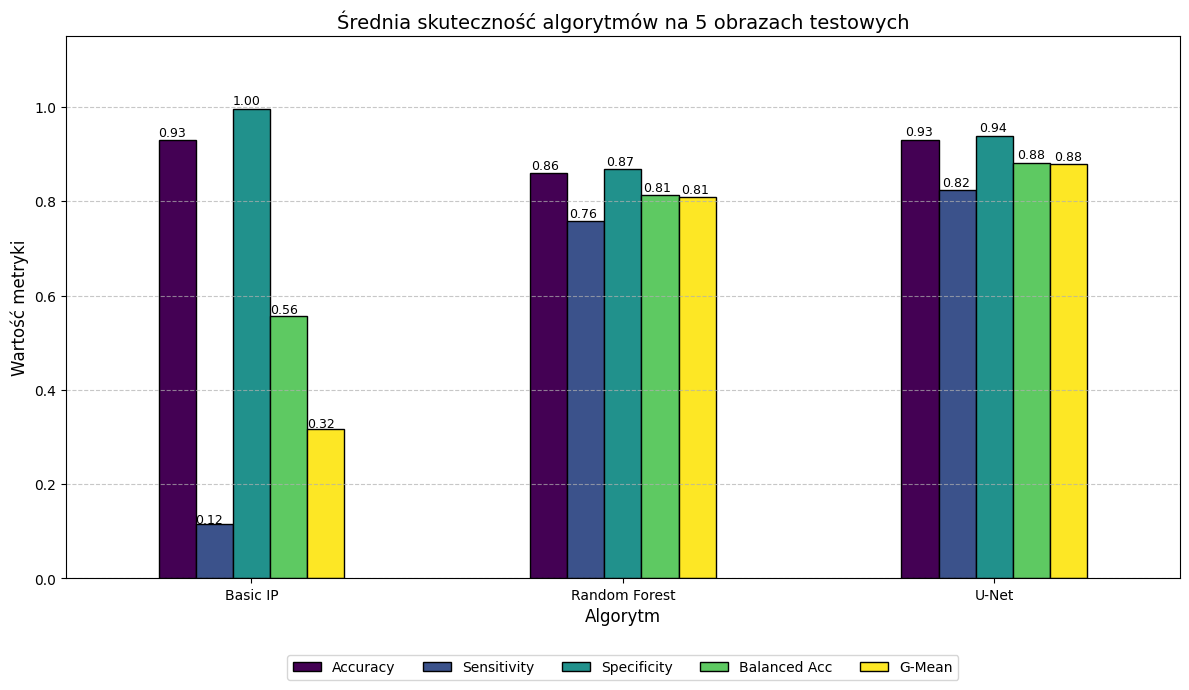

In [6]:
ax = df_summary.plot(kind="bar", figsize=(12, 7), colormap="viridis", edgecolor="black")
plt.title("Średnia skuteczność algorytmów na 5 obrazach testowych", fontsize=14)
plt.ylabel("Wartość metryki", fontsize=12)
plt.xlabel("Algorytm", fontsize=12)
plt.ylim(0, 1.15)  # Miejsce na etykiety u góry i legendę
plt.xticks(rotation=0)

# Legenda ląduje na dole poza ramką
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Podpisanie konkretnych wartości na słupkach
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() * 1.005, p.get_height() * 1.01), fontsize=9)

plt.tight_layout()
plt.show()